In [7]:
import pandas as pd
import os
import pyprojroot, sys
from pyprojroot.criterion import has_file
sys.path.insert(0, str(pyprojroot.find_root(has_file("pyproject.toml"))))

from dotenv import load_dotenv,find_dotenv

# load_dotenv()

env_file_path = find_dotenv()
print("当前加载的 .env 文件路径:", env_file_path)
# 2. 加载该文件
load_dotenv(env_file_path, override=True)

当前加载的 .env 文件路径: /workspace/worker/kdwk/Chrono/genuis/mizar/.env


True

In [8]:
filename = "/workspace/worker/kdwk/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/result/1050993377466233/metrics/test_results.csv"

In [3]:
dt1 = pd.read_csv(filename)

In [22]:
left_code = 'RB'
right_code ='HC'

In [23]:
left_data = dt1[dt1['code'] == left_code]
right_data= dt1[dt1['code'] == right_code]

In [9]:
from lib.cux001 import FactorEvaluate1

In [13]:
left_data

,trade_time,code,label_valid,confidence,neutral_weight,is_neutral,action_raw,action_soft,reward_scaled,future_ret_h,net_er_out,er_value,current_ret
82420,2025-05-06 09:00:00,RB,True,0.983252,0.008661,False,"[-0.6109,0.5731,-0.8013]","[0.0087,0.9873,0.0040]",-1.253521,-0.000823,0.983252,0.983252,-0.000823
82421,2025-05-06 09:01:00,RB,True,0.490133,0.092270,False,"[-0.5385,-0.0323,-0.3343]","[0.0923,0.6989,0.2088]",-1.332228,-0.001754,0.490133,0.490133,-0.001754
82422,2025-05-06 09:02:00,RB,True,0.885874,0.037373,False,"[-0.5902,0.2118,-0.5836]","[0.0374,0.9243,0.0384]",-1.070272,-0.000779,0.885874,0.885874,-0.000779
82423,2025-05-06 09:03:00,RB,True,0.990526,0.005053,False,"[-0.6331,0.6870,-0.8398]","[0.0051,0.9927,0.0022]",0.223888,0.000146,0.990526,0.990526,0.000146
82424,2025-05-06 09:04:00,RB,True,0.991829,0.004537,False,"[-0.6260,0.7213,-0.8547]","[0.0045,0.9936,0.0018]",-1.311877,-0.000853,0.991829,0.991829,-0.000853
...,...,...,...,...,...,...,...,...,...,...,...,...,...
165125,2026-04-29 22:57:00,RB,True,0.990457,0.004628,False,"[-0.6754,0.6667,-0.8337]","[0.0046,0.9929,0.0025]",1.071220,0.000698,0.990457,0.990457,0.000698
165126,2026-04-29 22:58:00,RB,True,0.989130,0.005323,False,"[-0.6573,0.6496,-0.8203]","[0.0053,0.9919,0.0028]",1.031777,0.000673,0.989130,0.989130,0.000673
165127,2026-04-29 22:59:00,RB,True,0.992585,0.003873,False,"[-0.6661,0.7209,-0.8616]","[0.0039,0.9944,0.0018]",1.371221,0.000891,0.992585,0.992585,0.000891
165128,2026-04-29 23:00:00,RB,True,0.967508,0.015978,False,"[-0.5896,0.4384,-0.7547]","[0.0160,0.9758,0.0083]",0.637079,0.000425,0.967508,0.967508,0.000425


In [27]:
left_evaluate1 = FactorEvaluate1(factor_data=left_data,
                                factor_name='net_er_out',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression=left_code,
                                resampling_win=5)

In [28]:
left_stats_dt = left_evaluate1.run()

In [29]:
left_stats_dt

{'total_ret': 0.12943388049006987,
 'avg_ret': 7.441772101647867e-06,
 'max_dd': -0.16617928272208038,
 'calmar': 0.7927208388583433,
 'sharpe1': 0.008579853674435227,
 'sharpe2': 0.8511593280738536,
 'turnover': 0.7742028379613254,
 'win_rate': 0.5026123301985371,
 'profit_ratio': 1.0265714586664971,
 'total_ic': 0.007726682595932728,
 'ic_mean': 0.007534712800951852,
 'ic_std': 0.2715576609546699,
 'ic_ir': 0.0277462722814128,
 'factor_autocorr': 0.06220016403738252,
 'ret_autocorr': 0.1341408383865823,
 'factor_coverage': 1.0,
 'factor_mean': 0.38104698764540845,
 'factor_std': 0.8306784463222695,
 'factor_skew': -0.7415494204879548,
 'factor_kurtosis': -1.367950168129792}

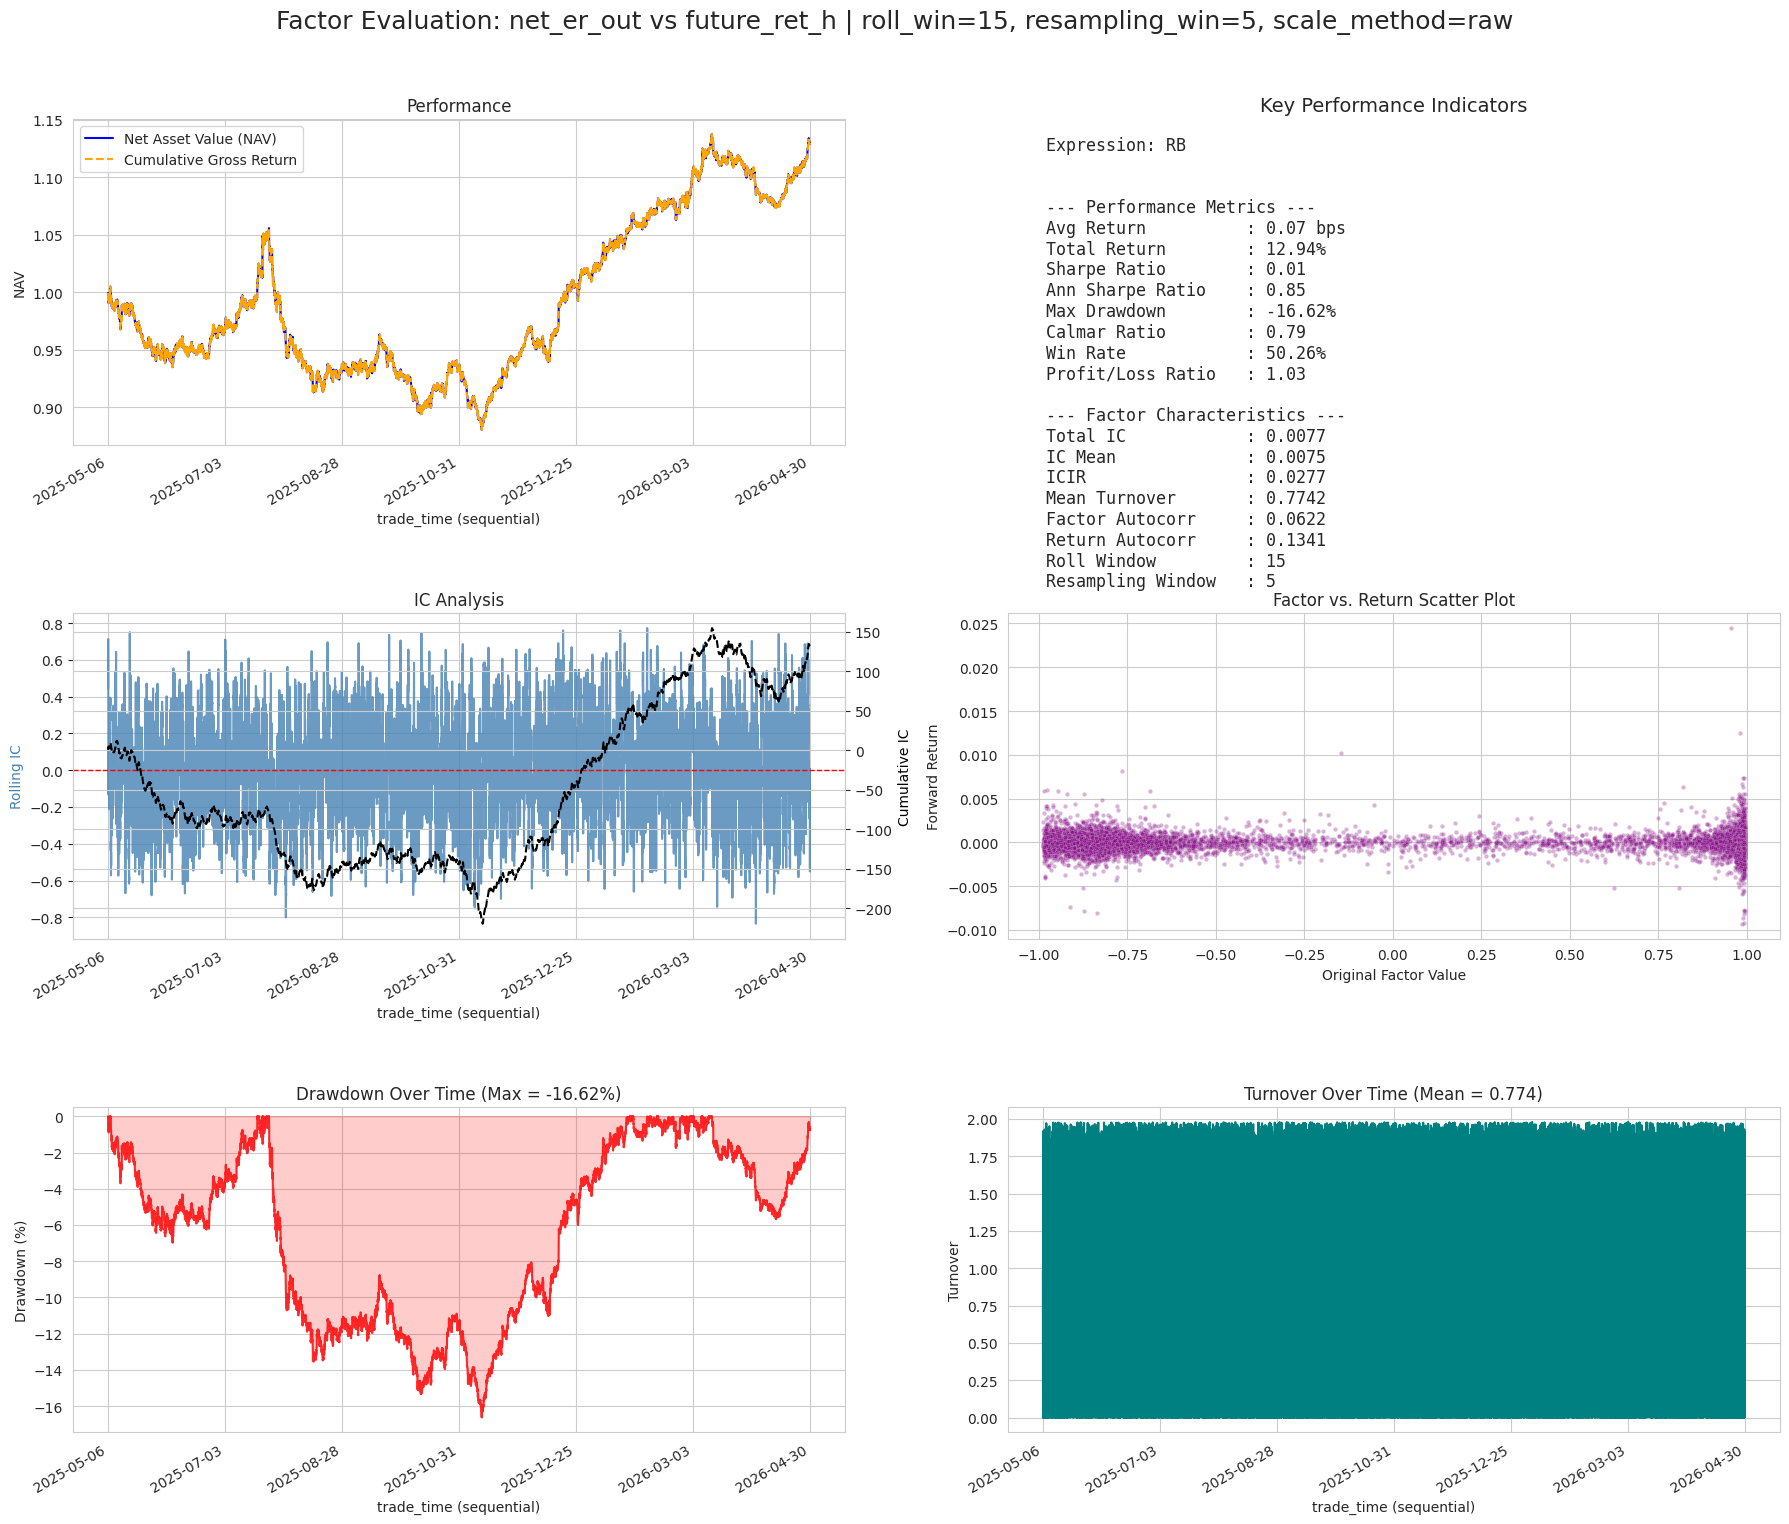

In [30]:
left_evaluate1.plot_results()

In [31]:
right_evaluate1 = FactorEvaluate1(factor_data=right_data,
                                factor_name='net_er_out',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression=right_code,
                                resampling_win=5)

In [32]:
right_stats_dt = right_evaluate1.run()

In [34]:
right_stats_dt

{'total_ret': 0.0073388553497610864,
 'avg_ret': 7.717831990877506e-07,
 'max_dd': -0.12221653518517173,
 'calmar': 0.061055296662149455,
 'sharpe1': 0.0009357478172008434,
 'sharpe2': 0.10346661253028443,
 'turnover': 0.768738482696233,
 'win_rate': 0.5012990080302314,
 'profit_ratio': 1.0028336617915132,
 'total_ic': -0.0037137837166651123,
 'ic_mean': -0.0034899482113714187,
 'ic_std': 0.267769413801776,
 'ic_ir': -0.013033408714689696,
 'factor_autocorr': 0.065171117054668,
 'ret_autocorr': 0.09602624787534433,
 'factor_coverage': 1.0,
 'factor_mean': 0.385475909269595,
 'factor_std': 0.8295726871087546,
 'factor_skew': -0.7531319996893773,
 'factor_kurtosis': -1.3507282517442534}

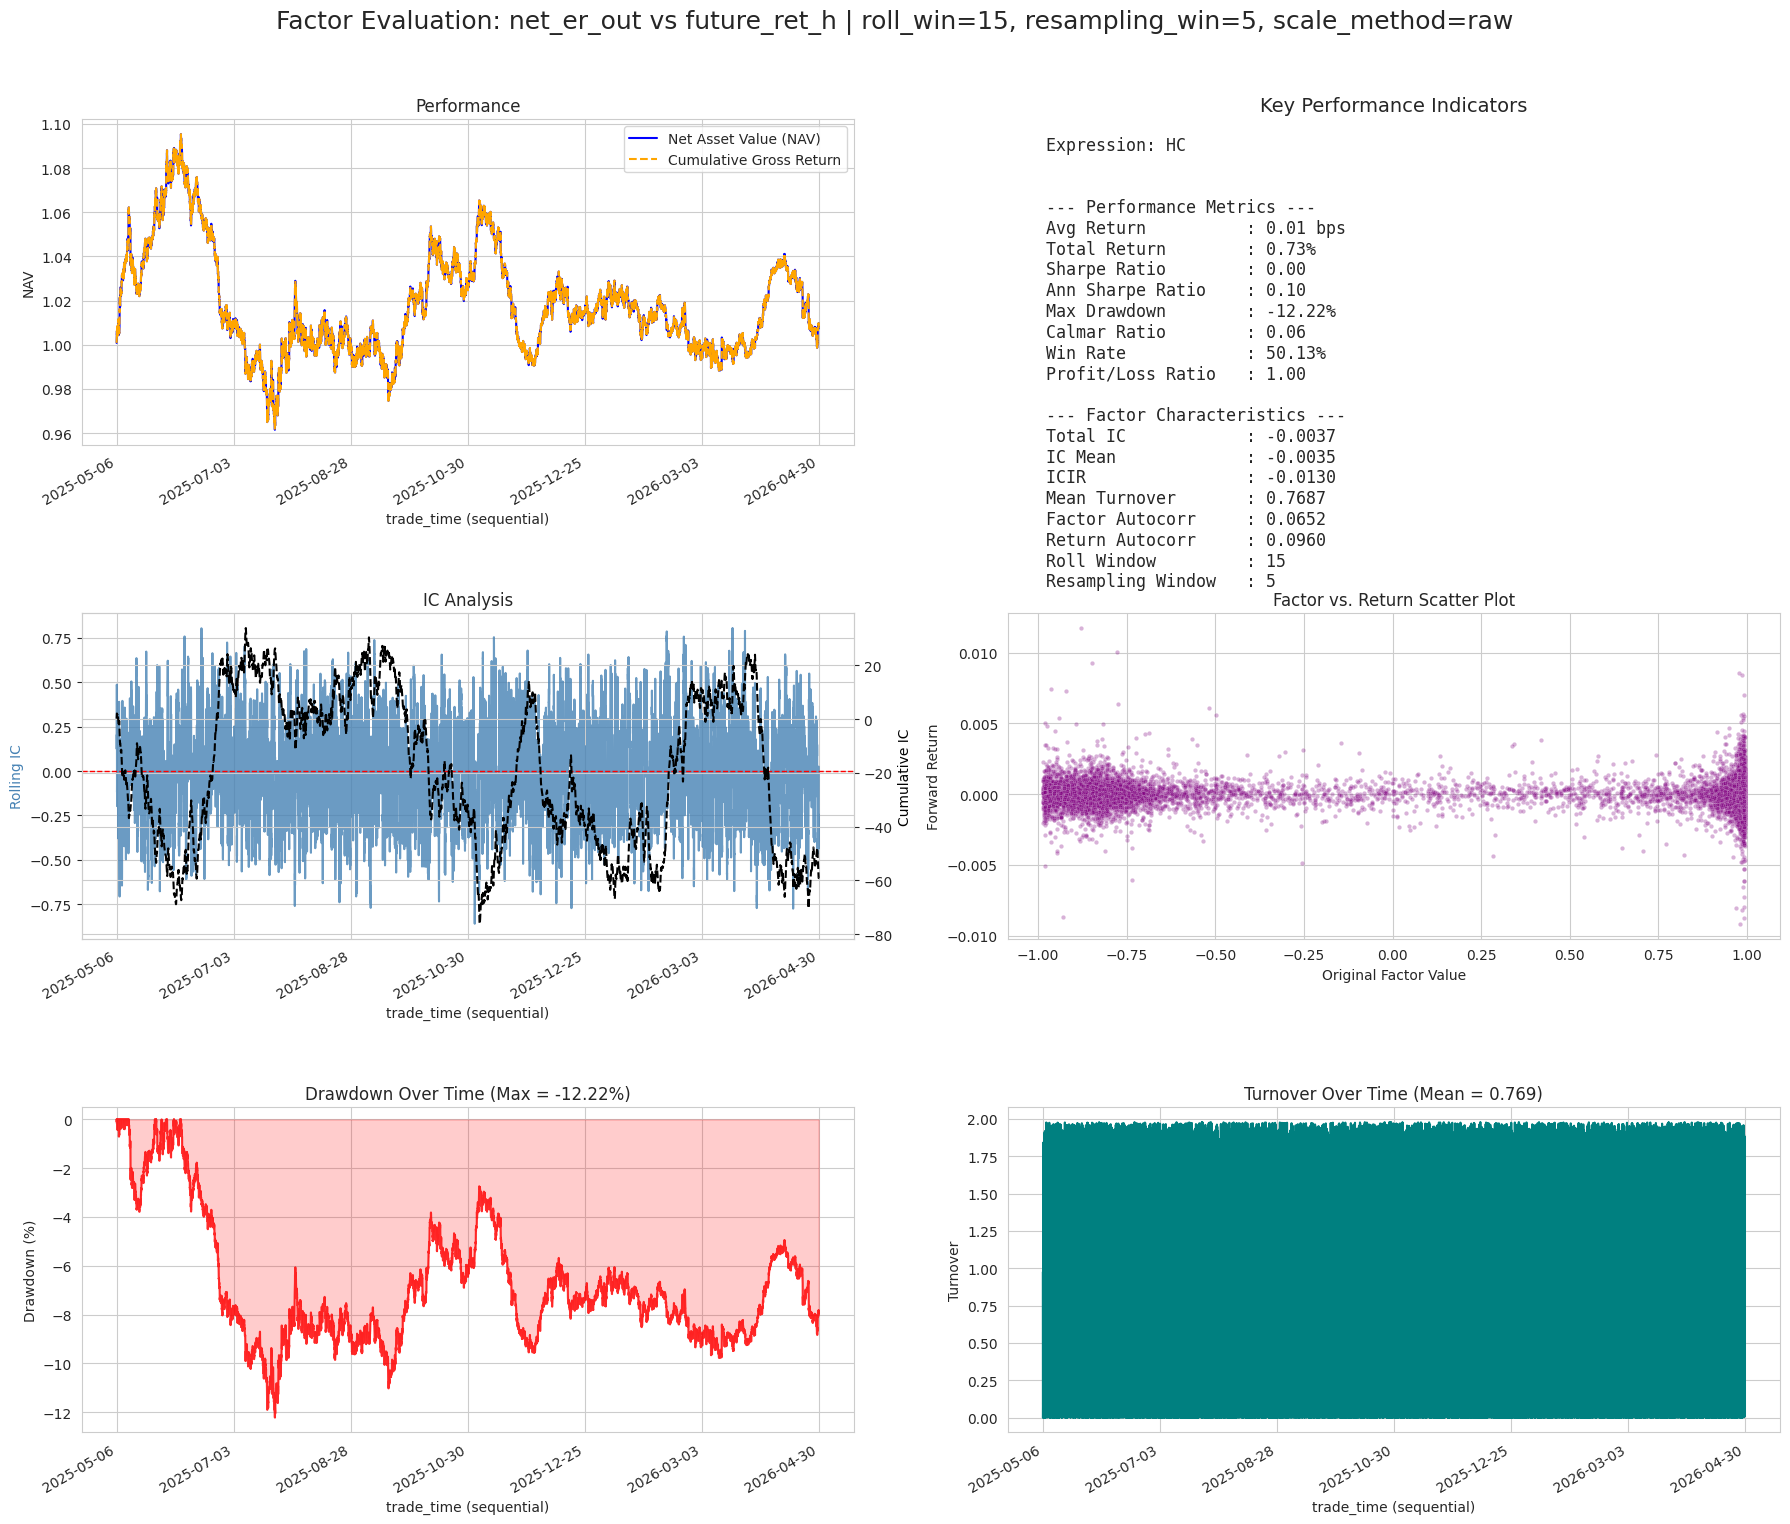

In [33]:
right_evaluate1.plot_results()

In [2]:
import pandas as pd

In [6]:
dt1 = pd.read_csv("/workspace/worker/kdwk/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/hybrid_transformer_loss/result/ensemble/s42_1048239198485335_s2026_1026780123442923_s3407_1056628310147615/test/ensemble_equal_predictions.csv")

In [11]:
dt1.columns

Index(['trade_time', 'code', 'evaluation_segment', 'label_valid', 'action_raw',
       'prediction_bound_std', 'predicted_z', 'target_z', 'predicted_ret_h',
       'future_ret_h', 'prediction_error_z', 'squared_error_z', 'ret_scale',
       'direction', 'confidence', 'net_er_out', 'er_value'],
      dtype='object')

| 字段 | 含义 | 用途 |
|---|---|---|
| `predicted_z` | 标准化预测收益 | ER、信号转换、IC、分层 |
| `future_ret_h` | 真实未来5分钟原始收益 | 绩效收益、IC目标 |
| `predicted_ret_h` | 还原到原始量纲的预测收益 | 校准和预测误差分析 |
| `target_z` | 标准化真实收益 | 模型损失、标准化MSE |
| `direction` | 预测值的正负方向 | 诊断字段，不建议直接交易 |
| `confidence` | `abs(predicted_z)` | 预测强度 |
| `er_value` | 当前等于`predicted_z` | 兼容性输出 |
| `net_er_out` | 当前等于`predicted_z` | 兼容性输出 |
| `squared_error_z` | 标准化预测平方误差 | MSE评价 |
| `ret_scale` | 对应品种训练集收益标准差 | 恢复收益率量纲 |

In [46]:
import numpy as np
dt1_rb = dt1[dt1['code'] == 'RB'][['trade_time','code','predicted_z','future_ret_h']]
dt1_rb['predicted_m'] = np.clip(dt1_rb['predicted_z'] / 0.1, -1.0, 1.0)
dt1_rb.head()

,trade_time,code,predicted_z,future_ret_h,predicted_m
82420,2025-05-06 09:00:00,RB,0.151312,-0.000823,1.000000
82421,2025-05-06 09:01:00,RB,0.091338,-0.001754,0.913378
82422,2025-05-06 09:02:00,RB,0.062250,-0.000779,0.622498
82423,2025-05-06 09:03:00,RB,0.061061,0.000146,0.610605
82424,2025-05-06 09:04:00,RB,0.023448,-0.000853,0.234475


In [47]:
dt1_hc = dt1[dt1['code'] == 'HC'][['trade_time','code','predicted_z','future_ret_h']]
dt1_hc.head()

,trade_time,code,predicted_z,future_ret_h
0,2025-05-06 09:00:00,HC,0.122218,-0.000874
1,2025-05-06 09:01:00,HC,0.067148,-0.002182
2,2025-05-06 09:02:00,HC,0.048081,-0.000494
3,2025-05-06 09:03:00,HC,0.050680,0.000324
4,2025-05-06 09:04:00,HC,0.020529,-0.001086


In [49]:
evaluate1 = FactorEvaluate1(factor_data=dt1_rb,
                                factor_name='predicted_m',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='RB',
                                resampling_win=5)

In [50]:
stats_dt = evaluate1.run()

In [51]:
stats_dt

{'total_ret': 0.10440351822319949,
 'avg_ret': 5.865320790583121e-06,
 'max_dd': -0.03456306129874265,
 'calmar': 3.0737444760948276,
 'sharpe1': 0.0130811106927004,
 'sharpe2': 1.3490355415687454,
 'turnover': 0.38766849624043864,
 'win_rate': 0.510739579705097,
 'profit_ratio': 1.0510966009726501,
 'total_ic': 0.013419907935913319,
 'ic_mean': 0.05603424798372945,
 'ic_std': 0.27011939928130946,
 'ic_ir': 0.20744251665306684,
 'factor_autocorr': 0.3076432933392655,
 'ret_autocorr': 0.1341408383865823,
 'factor_coverage': 1.0,
 'factor_mean': 0.17560879233214427,
 'factor_std': 0.41277293888580097,
 'factor_skew': -0.28922020205162713,
 'factor_kurtosis': -0.23585065964603524}

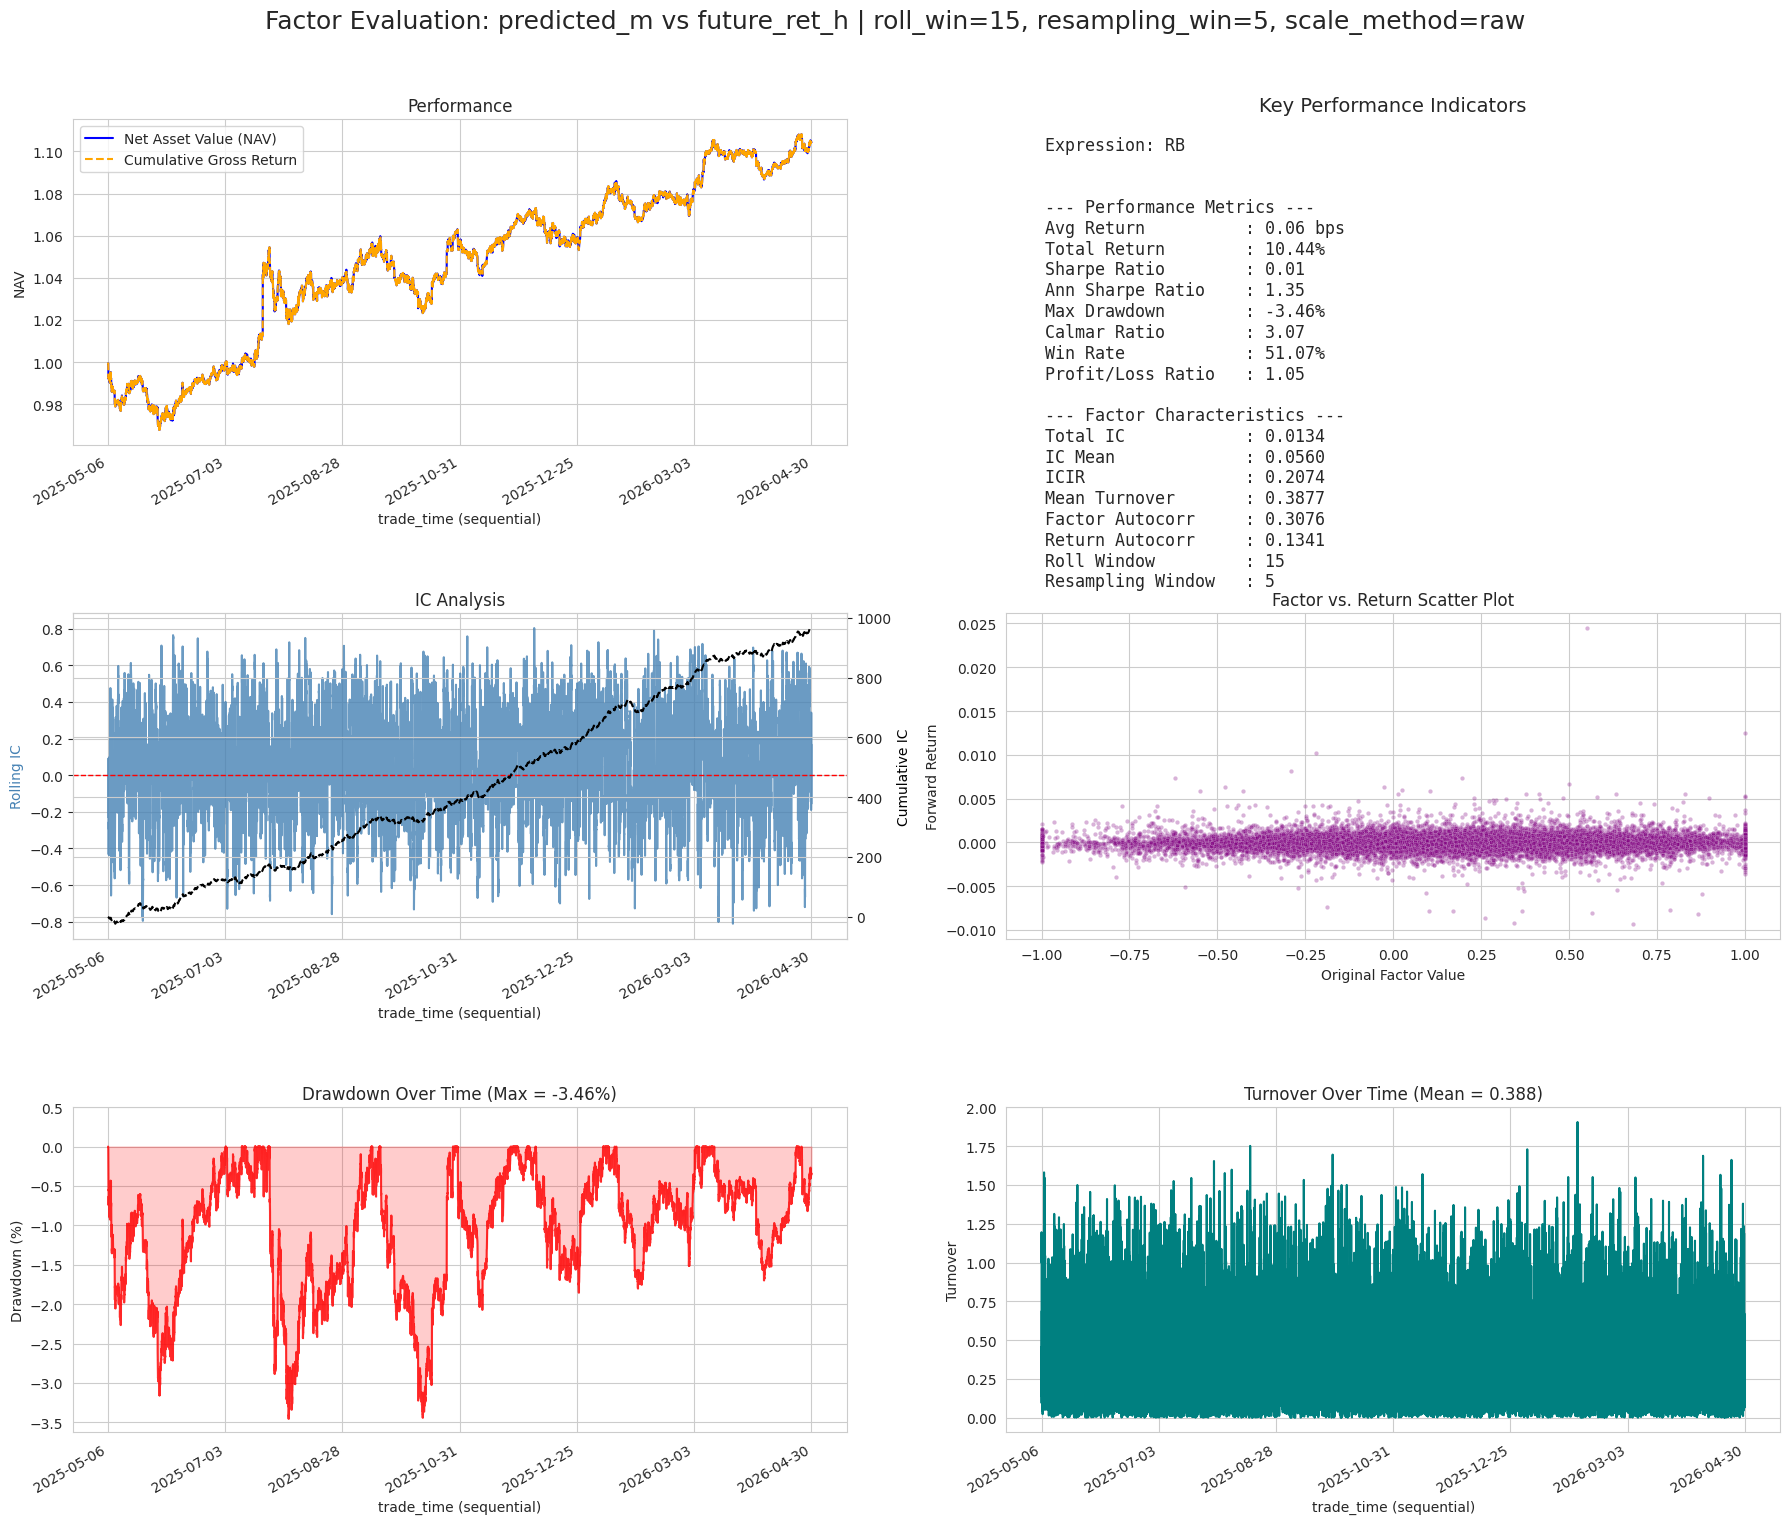

In [52]:
evaluate1.plot_results()